# IoT Traffic Analysis v8 — Packet-only (No Direction) (UNSW/Dryad)

This notebook implements **v8 packet-only**, but with the **direction feature removed** (set to 0).

Purpose (ablation): measure how much classification relies on knowing whether a packet is **uplink vs downlink**.

Notes:
- We keep the feature dimension the same as v8 packet-only (**F_DIM=17**) for easy comparison.
- The `direction` slot is always set to `0.0`.

This is the packet-side counterpart to the future `summary + no direction` notebook.


In [6]:
# If running in a fresh environment, install deps as needed:
# !pip install scapy tensorflow scikit-learn pandas numpy matplotlib

import os
import math
import random
import numpy as np
import pandas as pd

from scapy.all import PcapReader
from scapy.layers.inet import IP, TCP, UDP, ICMP

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1) Dataset location
Set `PCAP_DIR` to the folder where you extracted `pcaps.zip` from the Dryad dataset.


In [7]:
# === UPDATE THIS PATH ===
PCAP_DIR = "unsw-dataset/pcaps"   # e.g. "/content/pcaps" or "./pcaps"

assert os.path.isdir(PCAP_DIR), f"PCAP_DIR not found: {PCAP_DIR}"
pcap_files = sorted([os.path.join(PCAP_DIR, f) for f in os.listdir(PCAP_DIR) if f.endswith('.pcap')])

print("PCAP count:", len(pcap_files))
print("Example:", pcap_files[:3])


PCAP count: 26
Example: ['unsw-dataset/pcaps/AmazonEcho_44650d56ccd3.pcap', 'unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae.pcap', 'unsw-dataset/pcaps/AwairAirQuality_70886b100fc6.pcap']


## 2) v8 device-type taxonomy + mapping
Same mapping as the other v8 notebooks. We exclude `hub_gateway_bridge` by default.


In [8]:
from collections import Counter

device_to_type_v7 = {
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

v7_to_v8 = {
    "camera_streamer": "continuous_streaming",
    "sensor_meter": "low_rate_telemetry",
    "actuator_light_plug": "interactive_actuators",
    "media_speaker_display": "smart_media_clients",
    "hub_gateway_bridge": None,  # excluded
}

device_to_type_v8 = {dev: v7_to_v8.get(t, None) for dev, t in device_to_type_v7.items()}

DROP_NONE_TYPES = True

target_types = sorted([t for t in set(device_to_type_v8.values()) if t is not None])
print("v8 target types:", target_types)
print("Counts:", Counter([t for t in device_to_type_v8.values() if t is not None]))


v8 target types: ['continuous_streaming', 'interactive_actuators', 'low_rate_telemetry', 'smart_media_clients']
Counts: Counter({'continuous_streaming': 9, 'low_rate_telemetry': 7, 'smart_media_clients': 5, 'interactive_actuators': 4})


## 3) Build device table from PCAPs


In [9]:
def device_id_from_path(pcap_path: str) -> str:
    return os.path.basename(pcap_path).replace(".pcap", "")

rows = []
for p in pcap_files:
    dev = device_id_from_path(p)
    v8_type = device_to_type_v8.get(dev, None)
    if DROP_NONE_TYPES and v8_type is None:
        continue
    if v8_type is None:
        v8_type = "unknown_infrastructure"
    rows.append({"device_id": dev, "device_type": v8_type, "pcap_path": p})

df_dev = pd.DataFrame(rows).sort_values(["device_type", "device_id"]).reset_index(drop=True)
print("Devices included:", len(df_dev))
display(df_dev.head(10))
print(df_dev["device_type"].value_counts())


Devices included: 23


,device_id,device_type,pcap_path
0,AugustDoorBell_e076d03f00ae,continuous_streaming,unsw-dataset/pcaps/AugustDoorBell_e076d03f00ae...
1,BelkinCamera_b4750eece5a9,continuous_streaming,unsw-dataset/pcaps/BelkinCamera_b4750eece5a9.pcap
2,CanaryCamera_7c70bc5d5edc,continuous_streaming,unsw-dataset/pcaps/CanaryCamera_7c70bc5d5edc.pcap
3,NestDropCam_308cfb2fe4b2,continuous_streaming,unsw-dataset/pcaps/NestDropCam_308cfb2fe4b2.pcap
4,NetatmoWelcome_70ee50183443,continuous_streaming,unsw-dataset/pcaps/NetatmoWelcome_70ee50183443...
5,RingDoorBell_884aea31669d,continuous_streaming,unsw-dataset/pcaps/RingDoorBell_884aea31669d.pcap
6,SamsungCamera_00166cab6b88,continuous_streaming,unsw-dataset/pcaps/SamsungCamera_00166cab6b88....
7,TPLinkCamera_f4f26D9351f1,continuous_streaming,unsw-dataset/pcaps/TPLinkCamera_f4f26D9351f1.pcap
8,BelkinWemoSwitch_ec1a5979f489,interactive_actuators,unsw-dataset/pcaps/BelkinWemoSwitch_ec1a5979f4...
9,LiFXBulb_d073d5018308,interactive_actuators,unsw-dataset/pcaps/LiFXBulb_d073d5018308.pcap


device_type
continuous_streaming     8
low_rate_telemetry       6
smart_media_clients      5
interactive_actuators    4
Name: count, dtype: int64


## 4) Train/test split by device (stratified)


In [10]:
types = sorted(df_dev["device_type"].unique())
type_to_idx = {t: i for i, t in enumerate(types)}
idx_to_type = {i: t for t, i in type_to_idx.items()}
df_dev["y"] = df_dev["device_type"].map(type_to_idx).astype(int)

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df_dev,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df_dev["device_type"]
)

print("Train devices:", len(train_df), "Test devices:", len(test_df))
print("Train distribution:\n", train_df["device_type"].value_counts())
print("Test distribution:\n", test_df["device_type"].value_counts())


Train devices: 16 Test devices: 7
Train distribution:
 device_type
continuous_streaming     6
low_rate_telemetry       4
interactive_actuators    3
smart_media_clients      3
Name: count, dtype: int64
Test distribution:
 device_type
continuous_streaming     2
smart_media_clients      2
low_rate_telemetry       2
interactive_actuators    1
Name: count, dtype: int64


## 5) v8 packet-only features (No Direction)

Same feature vector as v8 packet-only (**F_DIM=17**), except `direction` is always `0.0`.


In [11]:
# Windowing
PKTS_PER_WINDOW = 60
STRIDE = 60
MAX_WINDOWS_PER_DEVICE = 1200

# Feature hyperparams
F_DIM = 17
IAT_CAP_SECONDS = 2.0
MTU_NORM = 1500.0

def safe_payload_len(pkt) -> int:
    if pkt.haslayer(TCP):
        return int(len(bytes(pkt[TCP].payload)))
    if pkt.haslayer(UDP):
        return int(len(bytes(pkt[UDP].payload)))
    return 0

def tcp_flag_bits(tcp_layer) -> np.ndarray:
    def has(flag_char):
        return 1.0 if flag_char in str(tcp_layer.flags) else 0.0
    return np.array([has("S"), has("A"), has("F"), has("R"), has("P"), has("U")], dtype=np.float32)

def is_keepalive_like(pkt) -> float:
    if not pkt.haslayer(TCP):
        return 0.0
    pl = safe_payload_len(pkt)
    if pl > 1:
        return 0.0
    fl = str(pkt[TCP].flags)
    if ("A" in fl) and ("S" not in fl) and ("F" not in fl) and ("R" not in fl) and len(pkt) <= 80:
        return 1.0
    return 0.0

def iter_feature_windows_no_direction(pcap_path: str,
                                      label: int,
                                      max_windows: int = MAX_WINDOWS_PER_DEVICE,
                                      pkts_per_window: int = PKTS_PER_WINDOW,
                                      stride: int = STRIDE):
    recent_tcp_keys = []
    recent_tcp_set = set()
    RECENT_MAX = 5000

    prev_time = None
    feats = []
    windows_yielded = 0

    with PcapReader(pcap_path) as pcap:
        for pkt in pcap:
            if not pkt.haslayer(IP):
                continue

            this_time = float(getattr(pkt, "time", 0.0))
            if prev_time is None or this_time <= 0.0 or prev_time <= 0.0:
                iat = 0.0
            else:
                iat = max(0.0, this_time - prev_time)
            prev_time = this_time
            iat = min(iat, IAT_CAP_SECONDS)

            pkt_len = float(len(pkt))
            payload_len = float(safe_payload_len(pkt))

            ip = pkt[IP]
            ttl = float(getattr(ip, "ttl", 0.0))

            # Direction removed
            direction = 0.0

            # Protocol one-hot
            proto = int(getattr(ip, "proto", 0))
            if proto == 6:
                proto_oh = np.array([1.0, 0.0, 0.0, 0.0], dtype=np.float32)
            elif proto == 17:
                proto_oh = np.array([0.0, 1.0, 0.0, 0.0], dtype=np.float32)
            elif proto == 1:
                proto_oh = np.array([0.0, 0.0, 1.0, 0.0], dtype=np.float32)
            else:
                proto_oh = np.array([0.0, 0.0, 0.0, 1.0], dtype=np.float32)

            flags = np.zeros(6, dtype=np.float32)
            is_retrans_like = 0.0
            if pkt.haslayer(TCP):
                tcp = pkt[TCP]
                flags = tcp_flag_bits(tcp)
                seq = int(getattr(tcp, "seq", 0))
                sport = int(getattr(tcp, "sport", 0))
                dport = int(getattr(tcp, "dport", 0))
                key = (ip.src, ip.dst, sport, dport, seq, int(payload_len))
                if key in recent_tcp_set:
                    is_retrans_like = 1.0
                recent_tcp_keys.append(key)
                recent_tcp_set.add(key)
                if len(recent_tcp_keys) > RECENT_MAX:
                    old = recent_tcp_keys.pop(0)
                    if old not in recent_tcp_keys:
                        recent_tcp_set.discard(old)

            keepalive = is_keepalive_like(pkt)

            pkt_len_norm = min(pkt_len / MTU_NORM, 2.0)
            payload_norm = min(payload_len / MTU_NORM, 2.0)
            ttl_norm = ttl / 255.0
            iat_norm = math.log1p(iat) / math.log1p(IAT_CAP_SECONDS)

            feat = np.concatenate([
                np.array([pkt_len_norm, payload_norm, iat_norm, direction, ttl_norm], dtype=np.float32),
                proto_oh,
                flags,
                np.array([is_retrans_like, keepalive], dtype=np.float32)
            ], axis=0).astype(np.float32)

            if feat.shape[0] != F_DIM:
                continue

            feats.append(feat)

            if len(feats) >= pkts_per_window:
                window = np.stack(feats[:pkts_per_window], axis=0)
                yield window, label
                windows_yielded += 1
                if windows_yielded >= max_windows:
                    break
                feats = feats[stride:]


## 6) tf.data pipeline


In [12]:
def make_window_generator(df_sub: pd.DataFrame):
    def gen():
        for _, row in df_sub.iterrows():
            pcap_path = row["pcap_path"]
            y = int(row["y"])
            for Xw, yw in iter_feature_windows_no_direction(pcap_path, label=y):
                yield Xw, yw
    return gen

output_signature = (
    tf.TensorSpec(shape=(PKTS_PER_WINDOW, F_DIM), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.int32),
)

def make_dataset(df_sub: pd.DataFrame, batch_size: int = 64, shuffle: bool = True):
    ds = tf.data.Dataset.from_generator(make_window_generator(df_sub), output_signature=output_signature)
    if shuffle:
        ds = ds.shuffle(2048, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

BATCH_SIZE = 64
train_ds = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
test_ds = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

print(train_ds)


2026-01-14 23:24:05.499437: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 60, 17), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## 7) Model (1D CNN)


In [13]:
def make_1d_cnn(n_classes: int) -> tf.keras.Model:
    inp = layers.Input(shape=(PKTS_PER_WINDOW, F_DIM), name="pkt_features")
    x = layers.Conv1D(64, 3, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(2)(x)

    x = layers.Conv1D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

n_classes = len(types)
model = make_1d_cnn(n_classes)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pkt_features (InputLayer)       │ (None, 60, 17)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 60, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 15, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,796 (632.02 KB)

 Trainable params: 160,900 (628.52 KB)

 Non-trainable params: 896 (3.50 KB)

## 8) Train


Epoch 1/25


2026-01-14 23:24:23.759594: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 78 of 2048
2026-01-14 23:24:33.856807: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 136 of 2048
2026-01-14 23:24:53.811097: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 236 of 2048
2026-01-14 23:25:13.898404: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 336 of 2048
2026-01-14 23:25:23.922231: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 376 of 2048
2026-01-14 23:25:43.795808: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while):

    285/Unknown 2218s 7s/step - accuracy: 0.9291 - loss: 0.2387

2026-01-15 00:01:03.823386: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


285/285 ━━━━━━━━━━━━━━━━━━━━ 2620s 8s/step - accuracy: 0.9483 - loss: 0.1885 - val_accuracy: 0.4543 - val_loss: 3.3696 - learning_rate: 0.0010
Epoch 2/25


...

2026-01-15 03:01:16.563932: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 152 of 2048
2026-01-15 03:01:36.537097: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 367 of 2048
2026-01-15 03:01:46.578537: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 477 of 2048
2026-01-15 03:01:56.580193: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 596 of 2048
2026-01-15 03:02:16.563036: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 813 of 2048
2026-01-15 03:02:36.568416: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while)

285/285 ━━━━━━━━━━━━━━━━━━━━ 1735s 6s/step - accuracy: 0.9695 - loss: 0.1025 - val_accuracy: 0.2866 - val_loss: 6.6111 - learning_rate: 5.0000e-04
Epoch 8/25


2026-01-15 03:30:11.653362: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 164 of 2048
2026-01-15 03:30:31.580674: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 418 of 2048
2026-01-15 03:30:41.600354: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 555 of 2048
2026-01-15 03:31:01.631852: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 803 of 2048
2026-01-15 03:31:21.606538: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 1057 of 2048
2026-01-15 03:31:41.574251: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while

285/285 ━━━━━━━━━━━━━━━━━━━━ 1714s 6s/step - accuracy: 0.9556 - loss: 0.1291 - val_accuracy: 0.2805 - val_loss: 4.7945 - learning_rate: 2.5000e-04


2026-01-15 03:58:35.309331: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


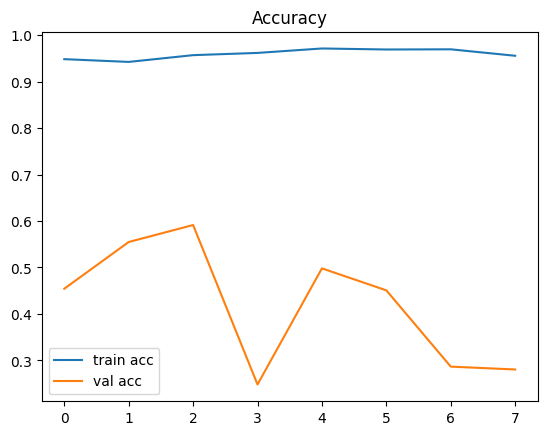

In [14]:
EPOCHS = 25

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5)
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

plt.figure()
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.show()


## 9) Evaluation


Window-level classification report:
                       precision    recall  f1-score   support

 continuous_streaming     0.6590    0.9275    0.7705       800
interactive_actuators     0.7316    0.6950    0.7128       400
   low_rate_telemetry     0.0000    0.0000    0.0000       408
  smart_media_clients     0.0845    0.1017    0.0923       462

             accuracy                         0.5155      2070
            macro avg     0.3688    0.4311    0.3939      2070
         weighted avg     0.4149    0.5155    0.4561      2070



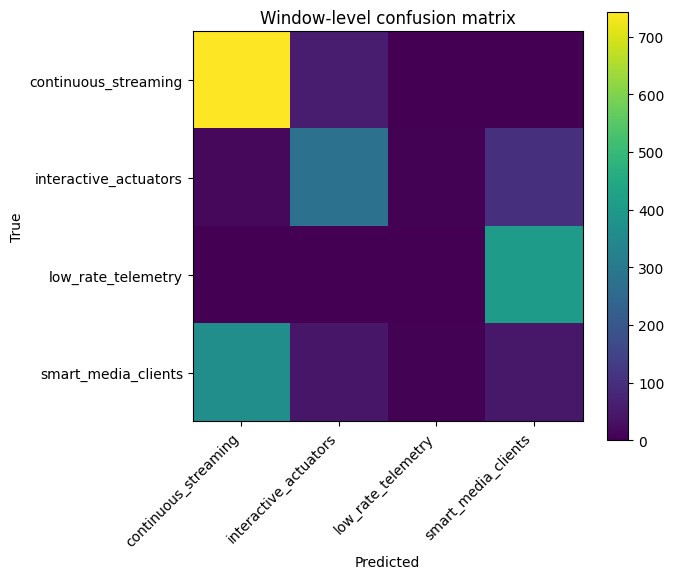


Per-device predictions:
- NestDropCam_308cfb2fe4b2            true=continuous_streaming   pred=continuous_streaming   windows=400
- PixStarPhotoFrame_e076d033bb85      true=smart_media_clients    pred=continuous_streaming   windows=400
- PhilipsHue_0017882b9a25             true=interactive_actuators  pred=interactive_actuators  windows=400
- BlipCareBPMeter_746a89002e25        true=low_rate_telemetry     pred=smart_media_clients    windows=8
- HelloBarbie_28c2ddffa52d            true=smart_media_clients    pred=smart_media_clients    windows=62
- WithingsSmartScale_0024e41b6f96     true=low_rate_telemetry     pred=smart_media_clients    windows=400
- SamsungCamera_00166cab6b88          true=continuous_streaming   pred=continuous_streaming   windows=400

Device-level classification report (mean-prob aggregation):
                       precision    recall  f1-score   support

 continuous_streaming     0.6667    1.0000    0.8000         2
interactive_actuators     1.0000    1.0000    1.

/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zer

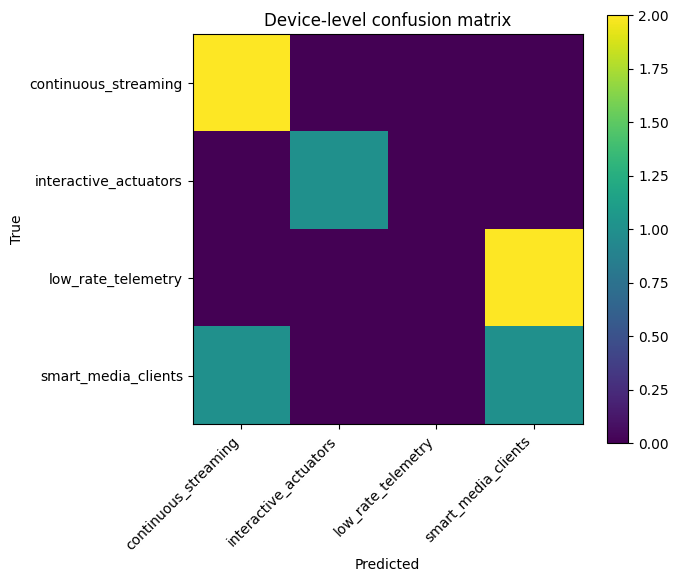

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

def collect_window_preds(df_sub: pd.DataFrame, model: tf.keras.Model, max_windows_per_device: int = 500):
    all_true = []
    all_pred = []
    per_device = []

    for _, row in df_sub.iterrows():
        dev = row["device_id"]
        y_true = int(row["y"])
        pcap_path = row["pcap_path"]

        probs = []
        wcount = 0
        for Xw, yw in iter_feature_windows_no_direction(pcap_path, label=y_true, max_windows=max_windows_per_device):
            p = model.predict(Xw[None, ...], verbose=0)[0]
            probs.append(p)
            y_hat = int(np.argmax(p))
            all_true.append(y_true)
            all_pred.append(y_hat)
            wcount += 1

        if probs:
            probs_mean = np.mean(np.stack(probs, axis=0), axis=0)
            y_dev = int(np.argmax(probs_mean))
        else:
            probs_mean = np.zeros((n_classes,), dtype=np.float32)
            y_dev = -1

        per_device.append((dev, y_true, probs_mean, y_dev, wcount))

    return np.array(all_true), np.array(all_pred), per_device

win_true, win_pred, dev_preds = collect_window_preds(test_df, model, max_windows_per_device=400)

print("Window-level classification report:")
print(classification_report(win_true, win_pred, target_names=types, digits=4))

cm = confusion_matrix(win_true, win_pred, labels=list(range(n_classes)))
plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Window-level confusion matrix")
plt.colorbar()
plt.xticks(range(n_classes), types, rotation=45, ha="right")
plt.yticks(range(n_classes), types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

dev_true = []
dev_pred = []
print("\nPer-device predictions:")
for dev, y_true, probs_mean, y_dev, wcount in dev_preds:
    if y_dev >= 0:
        dev_true.append(y_true)
        dev_pred.append(y_dev)
    print(f"- {dev:35s} true={idx_to_type[y_true]:22s} pred={idx_to_type.get(y_dev,'(none)'):22s} windows={wcount}")

dev_true = np.array(dev_true)
dev_pred = np.array(dev_pred)

print("\nDevice-level classification report (mean-prob aggregation):")
print(classification_report(dev_true, dev_pred, target_names=types, digits=4))

cm2 = confusion_matrix(dev_true, dev_pred, labels=list(range(n_classes)))
plt.figure(figsize=(7, 6))
plt.imshow(cm2, interpolation="nearest")
plt.title("Device-level confusion matrix")
plt.colorbar()
plt.xticks(range(n_classes), types, rotation=45, ha="right")
plt.yticks(range(n_classes), types)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 10) Notes
- This ablation removes direction entirely. Expect a noticeable drop in accuracy for classes that depend on uplink/downlink asymmetry.
- Next requested ablation: `summary + no direction`.
